In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.efficientnet import EfficientNet_B7_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device (use GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Data transforms (EfficientNet B7 uses 600x600 input)
train_transform = transforms.Compose([
    transforms.Resize(640),
    transforms.CenterCrop(600),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(640),
    transforms.CenterCrop(600),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (change path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform to val set (no augmentation)
val_dataset.dataset.transform = val_transform

# Data loaders (batch 16 due to B7 size; ~4-5GB VRAM usage, reduce to 8 if OOM)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)

# Class names
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train samples: 2088, Val samples: 523


In [3]:
# Load pre-trained EfficientNet B7
model = models.efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)

# Freeze all layers except classifier (transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Modify classifier for 5 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

# Move to GPU
model = model.to(device)

# Print model summary (optional)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Only train classifier first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 1.0280, Train Acc: 0.6504 | Val Loss: 0.8534, Val Acc: 0.7055
Epoch 2/100 - Train Loss: 0.7039, Train Acc: 0.7677 | Val Loss: 0.5982, Val Acc: 0.7859
Epoch 3/100 - Train Loss: 0.5953, Train Acc: 0.8075 | Val Loss: 0.5218, Val Acc: 0.8126
Epoch 4/100 - Train Loss: 0.5507, Train Acc: 0.8123 | Val Loss: 0.5033, Val Acc: 0.8222
Epoch 5/100 - Train Loss: 0.5158, Train Acc: 0.8257 | Val Loss: 0.4726, Val Acc: 0.8509
Epoch 6/100 - Train Loss: 0.4814, Train Acc: 0.8319 | Val Loss: 0.4553, Val Acc: 0.8394
Epoch 7/100 - Train Loss: 0.4545, Train Acc: 0.8506 | Val Loss: 0.4347, Val Acc: 0.8585
Epoch 8/100 - Train Loss: 0.4498, Train Acc: 0.8525 | Val Loss: 0.4277, Val Acc: 0.8509
Epoch 9/100 - Train Loss: 0.4252, Train Acc: 0.8539 | Val Loss: 0.4238, Val Acc: 0.8604
Epoch 10/100 - Train Loss: 0.4392, Train Acc: 0.8496 | Val Loss: 0.4129, Val Acc: 0.8604
Epoch 11/100 - Train Loss: 0.4168, Train Acc: 0.8496 | Val Loss: 0.4163, Val Acc: 0.8509
Epoch 12/100 - Train Loss: 0.4

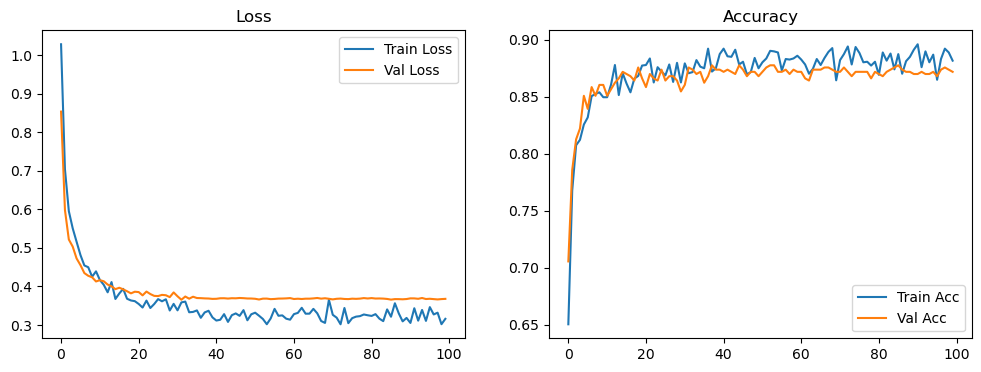

In [5]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)  # Adjust LR
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [6]:
# Predictions and report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
EfficientNet = os.path.join(model_path, 'EfficientNetB7')
os.makedirs(EfficientNet, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(EfficientNet, 'efficientnet_b7_100_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.76      0.79      0.77        90
      Cowpox       0.97      0.93      0.95       106
     Measles       0.97      0.91      0.94        91
   MonkeyPox       0.81      0.77      0.79       120
      Normal       0.87      0.96      0.91       116

    accuracy                           0.87       523
   macro avg       0.87      0.87      0.87       523
weighted avg       0.87      0.87      0.87       523

Accuracy: 0.8719
